In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 26.9 MB/s eta 0:00:00


In [3]:
import os
import cv2
import glob
import random
import shutil
import albumentations as A
from ultralytics import YOLO

# Dataset paths
images_dir = "/content/drive/MyDrive/Pruning/RoboFlow/train/images"
labels_dir = "/content/drive/MyDrive/Pruning/RoboFlow/train/labels"
# Create a dictionary of images: {base filename → full filename}
image_map = {os.path.splitext(f)[0]: f for f in os.listdir(images_dir)}

for img_file in os.listdir(images_dir):
    base_name = os.path.splitext(img_file)[0]
    # Find the label file that starts with the same base name as the image
    for lbl_file in os.listdir(labels_dir):
        if lbl_file.startswith(base_name):
            old_path = os.path.join(labels_dir, lbl_file)
            new_path = os.path.join(labels_dir, base_name + ".txt")
            os.rename(old_path, new_path)
            print(f" Renamed: {lbl_file} → {base_name}.txt")

# Find all images with various extensions
all_images = []
for ext in ["*.jpg", "*.JPG", "*.png", "*.PNG"]:
    all_images.extend(glob.glob(os.path.join(images_dir, ext)))

# Keep only images that have labels
images_with_labels = []
for img_path in all_images:
    label_path = os.path.join(labels_dir, os.path.splitext(os.path.basename(img_path))[0] + ".txt")
    if os.path.exists(label_path):
        images_with_labels.append(img_path)

print(f"Number of images with labels: {len(images_with_labels)}")

valid_classes = [0]  # Only valid classes

# : Scan and clean labels
def clean_labels(labels_path, valid_classes):
    for file in os.listdir(labels_path):
        if file.endswith(".txt"):
            path = os.path.join(labels_path, file)
            with open(path, "r") as f:
                lines = f.readlines()

            fixed_lines = []
            for line in lines:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    if cls_id in valid_classes:
                        fixed_lines.append(line)
                    else:
                        print(f" Invalid class {cls_id} in {file} removed")

            with open(path, "w") as f:
                f.writelines(fixed_lines)

print(" Scanning and cleaning labels ...")
clean_labels(labels_dir, valid_classes)
print(" Labels checked and cleaned")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 Renamed: 20230502_105422-pruned_jpg.rf.3bb2dcc5fa203e4de44d6fb7c3bca3c1.txt → 20230502_105422-pruned_jpg.rf.3bb2dcc5fa203e4de44d6fb7c3bca3c1.txt
 Renamed: 20230502_104827-pruned_jpg.rf.8c082327ce7d716ef436d397d3c790fd.txt → 20230502_104827-pruned_jpg.rf.8c082327ce7d716ef436d397d3c790fd.txt
 Renamed: 20230502_105419-pruned_jpg.rf.d98c4b3f68463e868c5acc1862b18c2e.txt → 20230502_105419-pruned_jpg.rf.d98c4b3f68463e868c5acc1862b18c2e.txt
 Renamed: 20230502_110134-pruned_jpg.rf.8b4206d581bb8bdbccaa746784a411d7.txt → 20230502_110134-pruned_jpg.rf.8b4206d581bb8bdbccaa746784a411d7.txt
 Renamed: 20230502_105813-pruned_jpg.rf.b0afd42bf5d96e7c7b49c61ded60390b.txt → 20230502_105813-pruned_jpg

In [4]:

# Dataset paths
images_dir = "/content/drive/MyDrive/Pruning/RoboFlow/train/images"
labels_dir = "/content/drive/MyDrive/Pruning/RoboFlow/train/labels"

aug_images_dir = "aug_images"
aug_labels_dir = "aug_labels"

os.makedirs(aug_images_dir, exist_ok=True)
os.makedirs(aug_labels_dir, exist_ok=True)

# Define augmentation transforms (slightly stronger)
transform = A.Compose([
    A.HorizontalFlip(p=0.7),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.7),
    A.Rotate(limit=30, p=0.6),
    A.RandomScale(scale_limit=0.3, p=0.5),
    A.ColorJitter(p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def read_labels(label_path):
    """
    Reads YOLO format labels from a .txt file.
    Returns bounding boxes and class labels.
    """
    boxes = []
    labels = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                cls, x, y, w, h = line.strip().split()
                cls = int(cls)
                boxes.append([float(x), float(y), float(w), float(h)])
                labels.append(cls)
    return boxes, labels

def save_labels(label_path, boxes, labels):
    """
    Saves bounding boxes and labels in YOLO format to a .txt file.
    """
    with open(label_path, 'w') as f:
        for lbl, box in zip(labels, boxes):
            f.write(f"{lbl} {' '.join(map(str, box))}\n")

# Collect all images (jpg and png)
image_paths = glob.glob(os.path.join(images_dir, "*.jpg")) + glob.glob(os.path.join(images_dir, "*.png"))
count = 0

# Loop through all images and apply augmentations
for img_path in image_paths:
    filename = os.path.basename(img_path)
    label_path = os.path.join(labels_dir, filename.replace(".jpg", ".txt").replace(".png", ".txt"))

    image = cv2.imread(img_path)
    boxes, labels = read_labels(label_path)

    # Skip if no labels are found
    if not boxes:
        continue

    # Apply augmentation 5 times per image
    for i in range(5):
        transformed = transform(image=image, bboxes=boxes, class_labels=labels)
        aug_img = transformed["image"]
        aug_boxes = transformed["bboxes"]
        aug_labels = transformed["class_labels"]

        new_img_name = f"{filename.split('.')[0]}_aug{i}.jpg"
        new_label_name = f"{filename.split('.')[0]}_aug{i}.txt"

        cv2.imwrite(os.path.join(aug_images_dir, new_img_name), aug_img)
        save_labels(os.path.join(aug_labels_dir, new_label_name), aug_boxes, aug_labels)
        count += 1

print(f" Data augmentation completed — {count} new images created.")


 Data augmentation completed — 25 new images created.


In [5]:
# Merge original and augmented images
final_images_dir = "dataset/images"
final_labels_dir = "dataset/labels"
os.makedirs(final_images_dir, exist_ok=True)
os.makedirs(final_labels_dir, exist_ok=True)

# Copy images from original and augmented directories
for src_dir, dst_dir in [(images_dir, final_images_dir), (aug_images_dir, final_images_dir)]:
    for file in glob.glob(os.path.join(src_dir, "*")):
        shutil.copy(file, dst_dir)

# Copy labels from original and augmented directories
for src_dir, dst_dir in [(labels_dir, final_labels_dir), (aug_labels_dir, final_labels_dir)]:
    for file in glob.glob(os.path.join(src_dir, "*")):
        shutil.copy(file, dst_dir)

print(" All data has been prepared in the dataset/ directory.")


 All data has been prepared in the dataset/ directory.


In [6]:
all_images = glob.glob(os.path.join(final_images_dir, "*.jpg"))
random.shuffle(all_images)
train_split = int(0.8 * len(all_images))
train_imgs = all_images[:train_split]
val_imgs = all_images[train_split:]

def copy_split(img_list, split_name):
    split_img_dir = f"dataset/{split_name}/images"
    split_lbl_dir = f"dataset/{split_name}/labels"
    os.makedirs(split_img_dir, exist_ok=True)
    os.makedirs(split_lbl_dir, exist_ok=True)

    for img_path in img_list:
        lbl_path = os.path.join(final_labels_dir, os.path.basename(img_path).replace(".jpg", ".txt"))
        shutil.copy(img_path, split_img_dir)
        if os.path.exists(lbl_path):
            shutil.copy(lbl_path, split_lbl_dir)

copy_split(train_imgs, "train")
copy_split(val_imgs, "val")

print(" Train/validation split done.")


 Train/validation split done.


In [7]:
import os
val_images_dir = "dataset/val/images"
val_labels_dir = "dataset/val/labels"

image_files = os.listdir(val_images_dir)
label_files = os.listdir(val_labels_dir)

print(f"Number of validation images: {len(image_files)}")
print(f"Number of validation labels: {len(label_files)}")

missing_labels = [img for img in image_files if img.replace('.jpg', '.txt').replace('.png', '.txt') not in label_files]
print(f"Images missing labels: {missing_labels}")


Number of validation images: 6
Number of validation labels: 6
Images missing labels: []


In [8]:
# Create data.yaml for a single class
with open("data.yaml", "w") as f:
    f.write(f"""
train: dataset/train/images
val: dataset/val/images

nc: 1
names: ['class0']
""")

print(" data.yaml file created.")

# Train YOLOv8 medium model and store training history
model = YOLO("yolov8m.pt")
history = model.train(data="data.yaml", epochs=60, imgsz=640, batch=16)

# Evaluate model on validation data
metrics = model.val(data="data.yaml", imgsz=640, batch=16)

 data.yaml file created.


Ultralytics 8.3.176 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=Fals

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

 16                  -1  1    332160  ultralytics.nn.modules.conv.Conv             [192, 192, 3, 2]              
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  2   1846272  ultralytics.nn.modules.block.C2f             [576, 384, 2]                 
 19                  -1  1   1327872  ultralytics.nn.modules.conv.Conv             [384, 384, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  2   4207104  ultralytics.nn.modules.block.C2f             [960, 576, 2]                 
 22        [15, 18, 21]  1   3776275  ultralytics.nn.modules.head.Detect           [1, [192, 384, 576]]          
Model summary: 169 layers, 25,856,899 parameters, 25,856,883 gradients, 79.1 GFLOPs

Transferred 469/475 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mi

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1723.9±1132.1 MB/s, size: 235.4 KB)


...


60 epochs completed in 0.081 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train/weights/best.pt, 52.0MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.176 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  7.83it/s]


                   all          6         78      0.831      0.462      0.594      0.321
Speed: 0.3ms preprocess, 15.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/train
Ultralytics 8.3.176 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3396.3±912.9 MB/s, size: 207.5 KB)


val: Scanning /content/dataset/val/labels.cache... 6 images, 0 backgrounds, 0 corrupt: 100%|██████████| 6/6 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  3.26it/s]


                   all          6         78      0.864      0.462      0.602      0.323
Speed: 0.2ms preprocess, 39.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/train2


In [9]:
# Extract and print mean evaluation metrics
precision = metrics.box.mp       # mean precision
recall    = metrics.box.mr       # mean recall
mAP50     = metrics.box.map50    # mAP@0.5
mAP5095   = metrics.box.map      # mAP@0.5:0.95

# Calculate F1-Score
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nAverage Evaluation Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"mAP@0.5: {mAP50:.4f}")
print(f"mAP@0.5:0.95: {mAP5095:.4f}")
print(f"F1-Score: {f1_score:.4f}")


Average Evaluation Metrics:
Precision: 0.8640
Recall: 0.4615
mAP@0.5: 0.6021
mAP@0.5:0.95: 0.3235
F1-Score: 0.6017


In [10]:
import json
from ultralytics import YOLO

# Prepare dictionary of all relevant metrics for object detection
metrics_dict = {
    "precision_mean": metrics.box.mp,
    "recall_mean": metrics.box.mr,
    "mAP50_mean": metrics.box.map50,
    "mAP50_95_mean": metrics.box.map,
    "F1-Score": f1_score
}

# Save to JSON file
with open("evaluation_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

print("Metrics saved to evaluation_metrics.json")

Metrics saved to evaluation_metrics.json


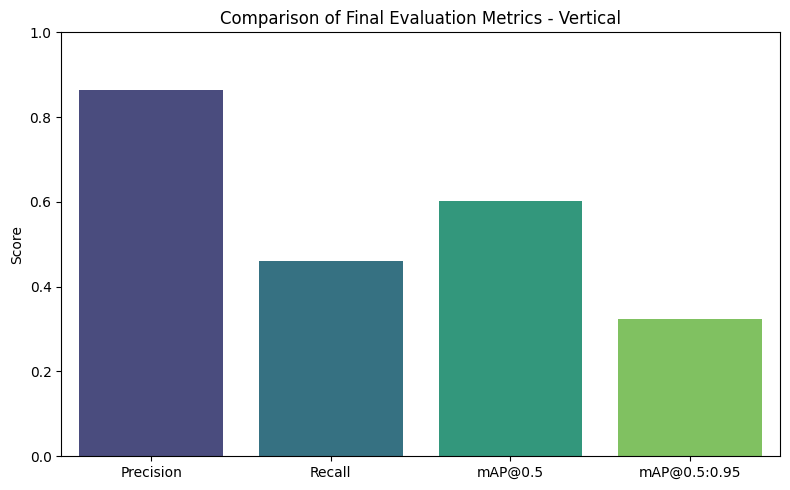

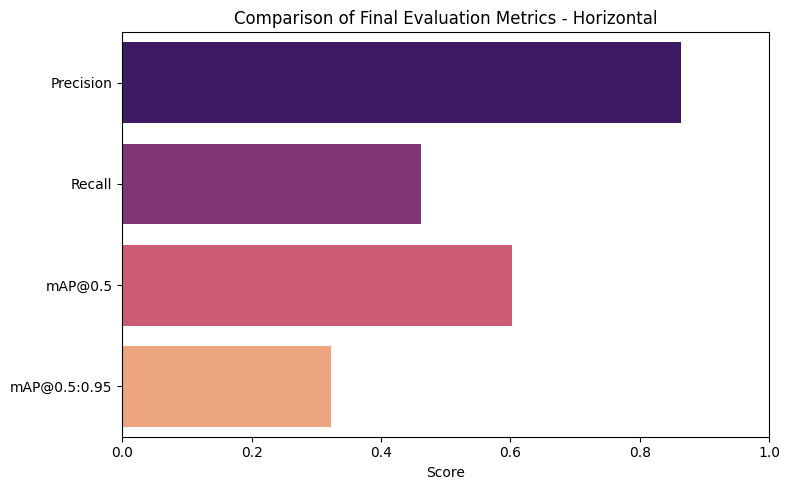

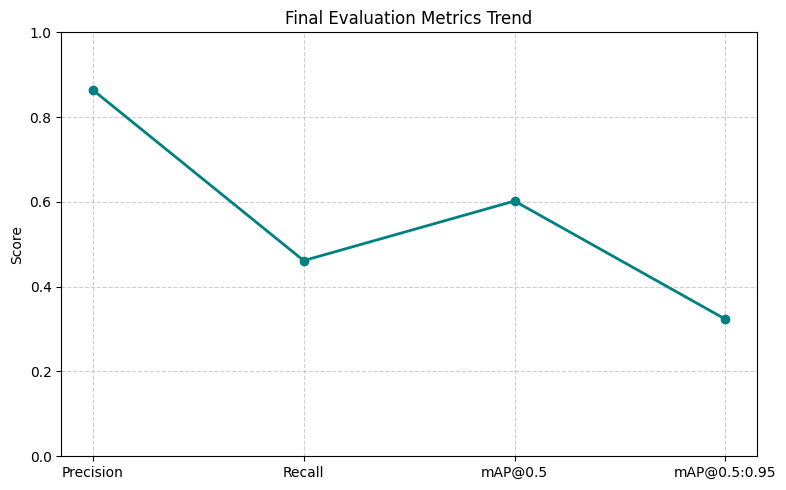

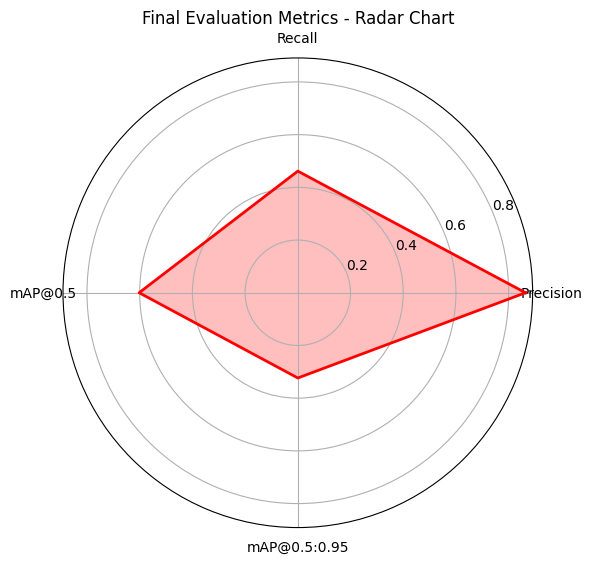

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data
metrics_names = ['Precision', 'Recall', 'mAP@0.5', 'mAP@0.5:0.95']
metrics_values = [metrics.box.mp, metrics.box.mr, metrics.box.map50, metrics.box.map]
#  Vertical Bar Chart
plt.figure(figsize=(8,5))
sns.barplot(x=metrics_names, y=metrics_values, palette='viridis')
plt.ylim(0, 1)
plt.title('Comparison of Final Evaluation Metrics - Vertical')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig('final_metrics_bar_vertical.png')
plt.show()

#  Horizontal Bar Chart
plt.figure(figsize=(8,5))
sns.barplot(x=metrics_values, y=metrics_names, palette='magma')
plt.xlim(0, 1)
plt.title('Comparison of Final Evaluation Metrics - Horizontal')
plt.xlabel('Score')
plt.tight_layout()
plt.savefig('final_metrics_bar_horizontal.png')
plt.show()

#  Line Plot
plt.figure(figsize=(8,5))
plt.plot(metrics_names, metrics_values, marker='o', color='teal', linewidth=2)
plt.ylim(0, 1)
plt.title('Final Evaluation Metrics Trend')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('final_metrics_line_plot.png')
plt.show()

#  Radar Chart
angles = np.linspace(0, 2*np.pi, len(metrics_names), endpoint=False).tolist()
metrics_values_circular = metrics_values + [metrics_values[0]]
angles_circular = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
ax.plot(angles_circular, metrics_values_circular, color='red', linewidth=2)
ax.fill(angles_circular, metrics_values_circular, color='red', alpha=0.25)
ax.set_xticks(angles)
ax.set_xticklabels(metrics_names)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'])
ax.set_title('Final Evaluation Metrics - Radar Chart', pad=25)
plt.tight_layout()
plt.savefig('final_metrics_radar_chart.png')
plt.show()


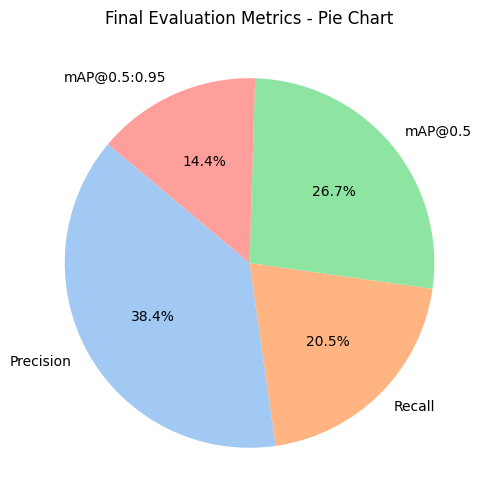

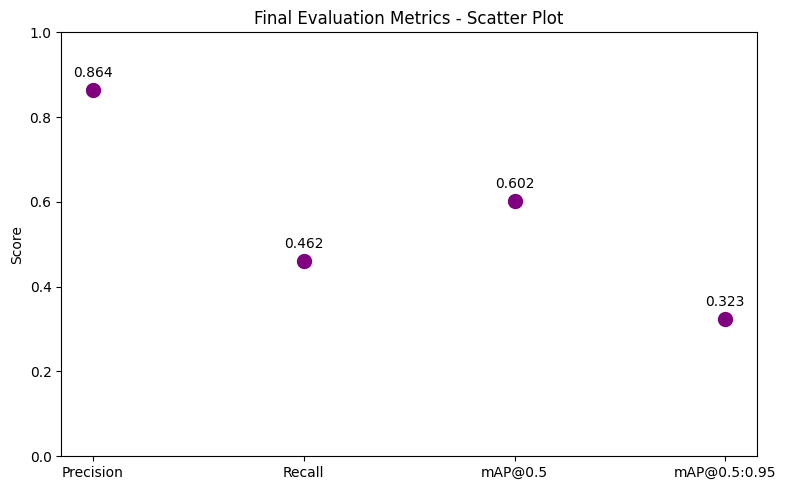

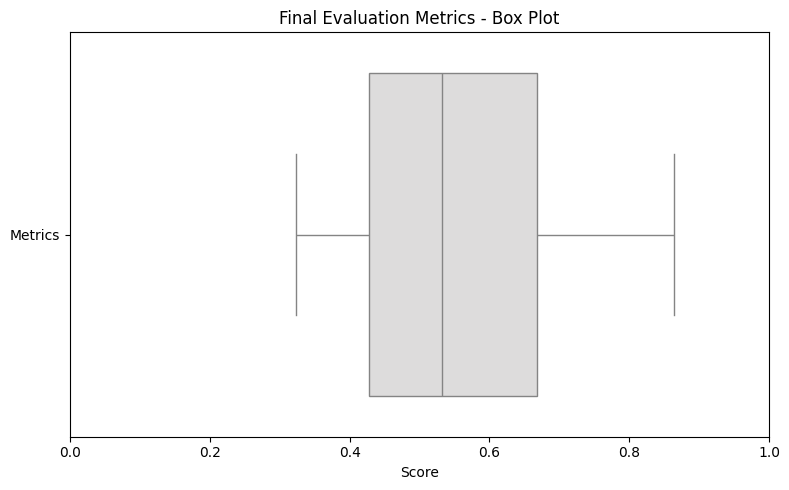

In [12]:
# Pie Chart
plt.figure(figsize=(6,6))
colors = sns.color_palette('pastel')[0:4]
plt.pie(metrics_values, labels=metrics_names, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Final Evaluation Metrics - Pie Chart')
plt.savefig('final_metrics_pie_chart.png')
plt.show()

# Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(metrics_names, metrics_values, color='purple', s=100)
for i, val in enumerate(metrics_values):
    plt.text(i, val + 0.03, f"{val:.3f}", ha='center')
plt.ylim(0, 1)
plt.title('Final Evaluation Metrics - Scatter Plot')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig('final_metrics_scatter_plot.png')
plt.show()

# Simple Box Plot (for demonstration, as we have single values)
plt.figure(figsize=(8,5))
sns.boxplot(data=metrics_values, orient='h', palette='coolwarm')
plt.yticks([0], ['Metrics'])
plt.title('Final Evaluation Metrics - Box Plot')
plt.xlabel('Score')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('final_metrics_box_plot.png')
plt.show()


Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


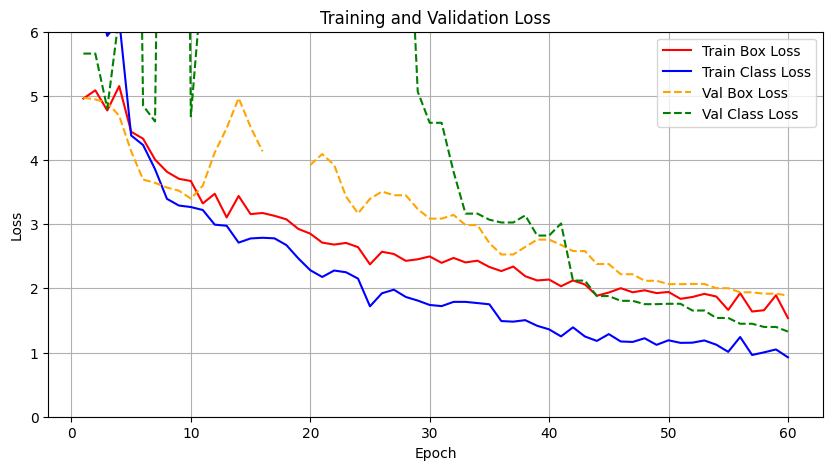

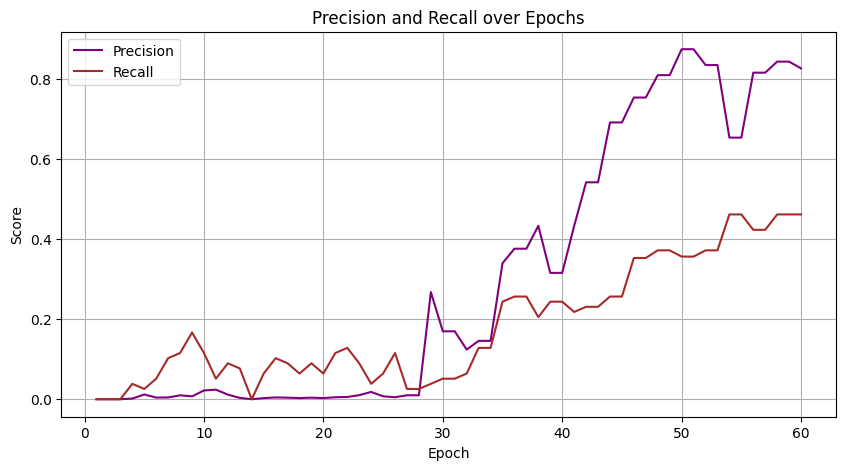

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = '/content/runs/detect/train/results.csv'

df = pd.read_csv(csv_path)

print(df.columns)

epochs = df['epoch']

train_box_loss = df['train/box_loss']
train_cls_loss = df['train/cls_loss']

val_box_loss = df['val/box_loss']
val_cls_loss = df['val/cls_loss']

precision = df['metrics/precision(B)']
recall = df['metrics/recall(B)']

plt.figure(figsize=(10,5))
plt.plot(epochs, train_box_loss, label='Train Box Loss', color='red')
plt.plot(epochs, train_cls_loss, label='Train Class Loss', color='blue')
plt.plot(epochs, val_box_loss, label='Val Box Loss', color='orange', linestyle='--')
plt.plot(epochs, val_cls_loss, label='Val Class Loss', color='green', linestyle='--')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 6)
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, precision, label='Precision', color='purple')
plt.plot(epochs, recall, label='Recall', color='brown')
plt.title('Precision and Recall over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.show()


In [21]:
import time
import statistics
from ultralytics import YOLO
import cv2
import glob
import os

# -----------------------
# CONFIG
# -----------------------
# Update model_path to point to the correct location of best.pt
model_path = "/content/runs/detect/train/weights/best.pt"
# Update img_path to use one of the validation images
val_images_dir = "dataset/val/images"
image_files = glob.glob(os.path.join(val_images_dir, "*"))
if image_files:
    img_path = image_files[0] # Use the first image found in the validation set
else:
    img_path = None # Set to None if no images are found

n_runs = 6  # number of iterations to average
conf_thres = 0.25  # confidence threshold
# -----------------------

# Load model
if img_path is not None:
    model = YOLO(model_path)

    # Warmup
    _ = model.predict(img_path, conf=conf_thres)

    # --- End-to-end latency ---
    end2end_times = []
    for _ in range(n_runs):
        start = time.time()
        _ = model.predict(img_path, conf=conf_thres)
        elapsed_ms = (time.time() - start) * 1000
        end2end_times.append(elapsed_ms)

    # --- Model-only latency ---
    # Preload image
    im = cv2.imread(img_path)
    assert im is not None, f"Image not found: {img_path}"

    # Convert to RGB as YOLO expects
    im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

    model_times = []
    for _ in range(n_runs):
        start = time.time()
        _ = model.predict(im_rgb, conf=conf_thres)
        elapsed_ms = (time.time() - start) * 1000
        model_times.append(elapsed_ms)

    # --- Reporting ---
    def report_times(times, label):
        print(f"\n=== {label} ===")
        print({
            'n': len(times),
            'min_ms': min(times),
            'median_ms': statistics.median(times),
            'p95_ms': statistics.quantiles(times, n=100)[94],
            'max_ms': max(times),
            'mean_ms': statistics.mean(times),
            'fps_median': 1000 / statistics.median(times),
            'fps_p95': 1000 / statistics.quantiles(times, n=100)[94]
        })

    report_times(end2end_times, "End-to-end (read + preproc + forward + NMS)")
    report_times(model_times, "Model-only (preproc + forward + NMS)")

else:
    print("No images found in the validation directory to measure latency.")


image 1/1 /content/dataset/val/images/20230502_104827-pruned_jpg.rf.8c082327ce7d716ef436d397d3c790fd.jpg: 640x640 23 class0s, 37.0ms
Speed: 2.2ms preprocess, 37.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset/val/images/20230502_104827-pruned_jpg.rf.8c082327ce7d716ef436d397d3c790fd.jpg: 640x640 23 class0s, 36.9ms
Speed: 1.7ms preprocess, 36.9ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset/val/images/20230502_104827-pruned_jpg.rf.8c082327ce7d716ef436d397d3c790fd.jpg: 640x640 23 class0s, 37.0ms
Speed: 2.3ms preprocess, 37.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset/val/images/20230502_104827-pruned_jpg.rf.8c082327ce7d716ef436d397d3c790fd.jpg: 640x640 23 class0s, 22.4ms
Speed: 1.6ms preprocess, 22.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset/val/images/20230502_104827-pruned_jpg.rf.8c08232